In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.cluster import AgglomerativeClustering
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_regression, SelectFromModel, RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.pipeline import make_pipeline
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)
print('selected_font:', selected_font)


selected_font: AppleGothic


In [2]:
station_path = '../../../Data/sort_data/preprocessed_6station/ST-481.csv'
df = pd.read_csv(station_path)

drop_mask = df['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')
dropped_rows = int(drop_mask.sum())
df = df.loc[~drop_mask].copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])

station_id = df['station_id'].iloc[0]
print(f"station_id: {station_id}")
print(f'dropped rows (종료_대여소_ID == X): {dropped_rows:,}')
print(f'rows after drop: {len(df):,}')
print(f"time range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

station_id: ST-481
dropped rows (종료_대여소_ID == X): 178
rows after drop: 71,453
time range: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00


In [3]:
hourly = (
    df.sort_values('timestamp')
      .groupby('timestamp')
      .agg(
          inflow=('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
          outflow=('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
          기준_날짜=('기준_날짜', 'first'),
          시간대=('시간대', 'first'),
          집계_기준=('집계_기준', 'first'),
          station_id=('station_id', 'first'),
          온도=('온도', 'first'),
          습도=('습도', 'first'),
          강수량=('강수량', 'first'),
          temp_lag_1hr=('temp_lag_1hr', 'first'),
          위도=('위도', 'first'),
          경도=('경도', 'first'),
          year=('year', 'first'),
          month=('month', 'first'),
          month_sin=('month_sin', 'first'),
          month_cos=('month_cos', 'first'),
          is_restingday=('is_restingday', 'first'),
          weekday_0=('weekday_0', 'first'),
          weekday_1=('weekday_1', 'first'),
          weekday_2=('weekday_2', 'first'),
          weekday_3=('weekday_3', 'first'),
          weekday_4=('weekday_4', 'first'),
          weekday_5=('weekday_5', 'first'),
          weekday_6=('weekday_6', 'first'),
          hour_sin=('hour_sin', 'first'),
          hour_cos=('hour_cos', 'first'),
          is_noon=('is_noon', 'first'),
          is_rushhour=('is_rushhour', 'first'),
          residential_index=('residential_index', 'first'),
          business_index=('business_index', 'first'),
          tourism_index=('tourism_index', 'first'),
          transit_index=('transit_index', 'first'),
          commute_in_index=('commute_in_index', 'first'),
          commute_out_index=('commute_out_index', 'first'),
          snow_flag=('snow_flag', 'first')
      )
      .reset_index()
)

hourly['total_flow'] = hourly['inflow'] + hourly['outflow']
hourly['net_flow'] = hourly['inflow'] - hourly['outflow']

hourly.head()

,timestamp,inflow,outflow,기준_날짜,시간대,집계_기준,station_id,온도,습도,강수량,...,is_rushhour,residential_index,business_index,tourism_index,transit_index,commute_in_index,commute_out_index,snow_flag,total_flow,net_flow
0,2024-01-01 00:00:00,2,2,2024-01-01,0,출발시간,ST-481,-2.7,92,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,4,0
1,2024-01-01 01:00:00,0,3,2024-01-01,1,출발시간,ST-481,-1.2,87,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,-3
2,2024-01-01 02:00:00,3,0,2024-01-01,2,출발시간,ST-481,-1.2,88,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,3
3,2024-01-01 03:00:00,1,2,2024-01-01,3,출발시간,ST-481,-1.1,88,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,-1
4,2024-01-01 05:00:00,2,2,2024-01-01,5,출발시간,ST-481,-1.0,87,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,4,0


In [4]:
display(hourly[['timestamp', 'station_id', '시간대', 'inflow', 'outflow', 'total_flow', 'net_flow']].head())
display(hourly[['inflow', 'outflow', 'total_flow', 'net_flow']].describe().T)

,timestamp,station_id,시간대,inflow,outflow,total_flow,net_flow
0,2024-01-01 00:00:00,ST-481,0,2,2,4,0
1,2024-01-01 01:00:00,ST-481,1,0,3,3,-3
2,2024-01-01 02:00:00,ST-481,2,3,0,3,3
3,2024-01-01 03:00:00,ST-481,3,1,2,3,-1
4,2024-01-01 05:00:00,ST-481,5,2,2,4,0


,count,mean,std,min,25%,50%,75%,max
inflow,7658.0,4.752677,4.349549,0.0,2.0,4.0,7.0,34.0
outflow,7658.0,4.817838,4.034086,0.0,2.0,4.0,7.0,30.0
total_flow,7658.0,9.570514,7.081850,1.0,4.0,8.0,13.0,54.0
net_flow,7658.0,-0.065161,4.498029,-21.0,-2.0,0.0,2.0,28.0


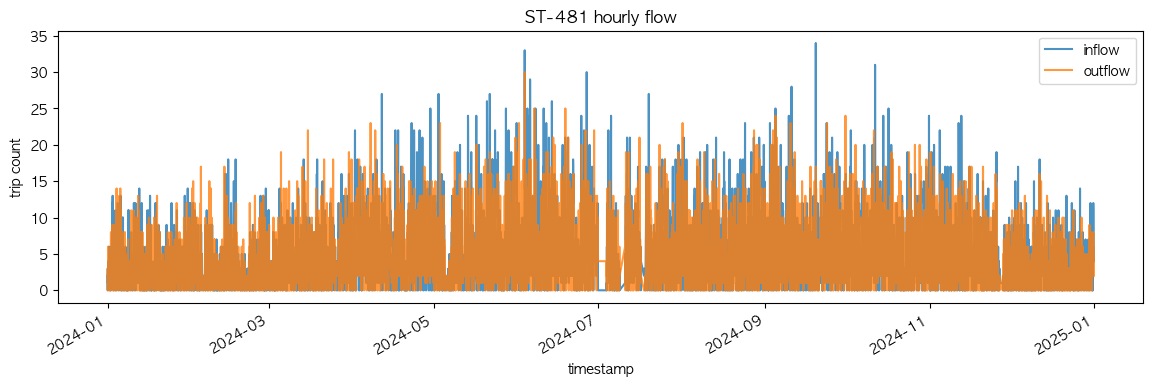

In [5]:
hourly.set_index('timestamp')[['inflow', 'outflow']].plot(alpha=0.8)
plt.title(f'{station_id} hourly flow')
plt.ylabel('trip count')
plt.show()

In [6]:
hourly['week_of_month'] = ((hourly['timestamp'].dt.day - 1) // 7) + 1
hourly['month_label'] = hourly['timestamp'].dt.strftime('%Y-%m')

monthly_weekly_usage = (
    hourly.groupby(['month_label', 'week_of_month'])[['inflow', 'outflow', 'total_flow', 'net_flow']]
          .sum()
          .reset_index()
)

monthly_weekly_usage.head(12)

,month_label,week_of_month,inflow,outflow,total_flow,net_flow
0,2024-01,1,540,526,1066,14
1,2024-01,2,452,465,917,-13
2,2024-01,3,419,443,862,-24
3,2024-01,4,449,397,846,52
4,2024-01,5,271,251,522,20
5,2024-02,1,500,519,1019,-19
6,2024-02,2,458,507,965,-49
7,2024-02,3,351,353,704,-2
8,2024-02,4,446,493,939,-47
9,2024-02,5,79,100,179,-21


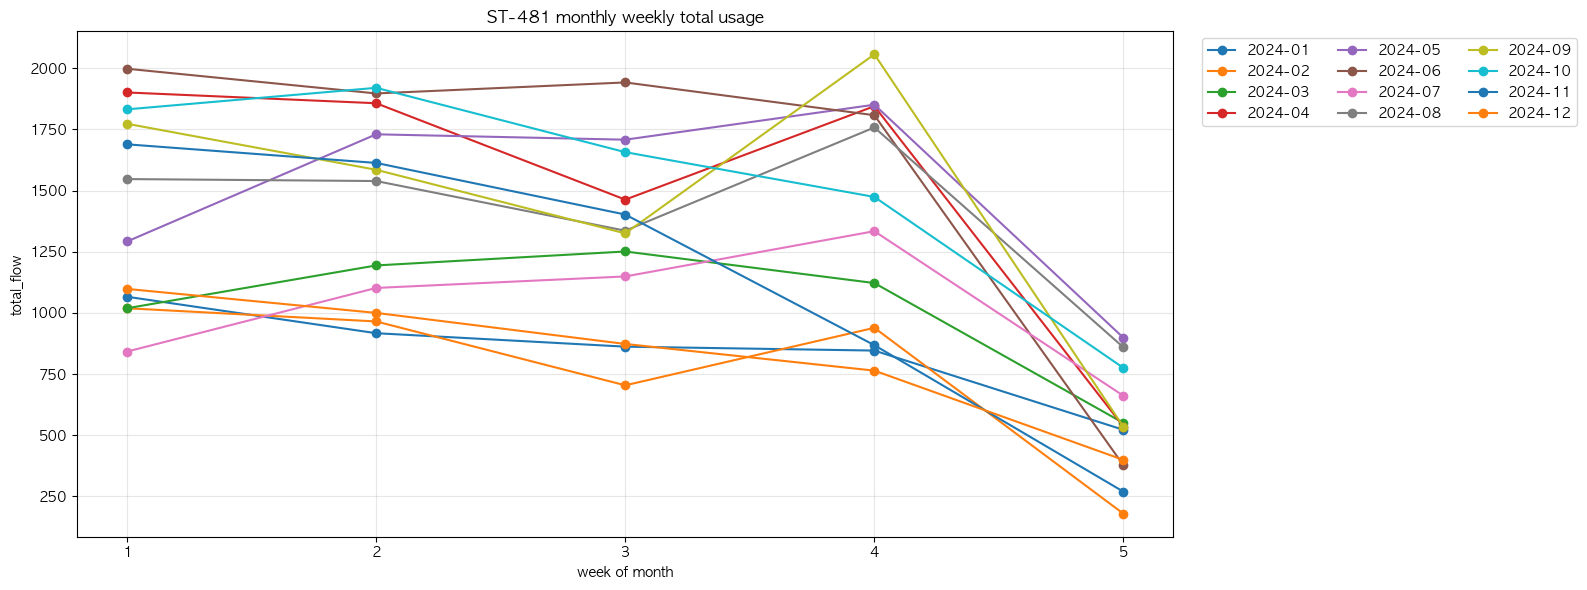

In [7]:
plt.figure(figsize=(16, 6))
for month_label, group in monthly_weekly_usage.groupby('month_label'):
    plt.plot(group['week_of_month'], group['total_flow'], marker='o', label=month_label)

plt.title(f'{station_id} monthly weekly total usage')
plt.xlabel('week of month')
plt.ylabel('total_flow')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

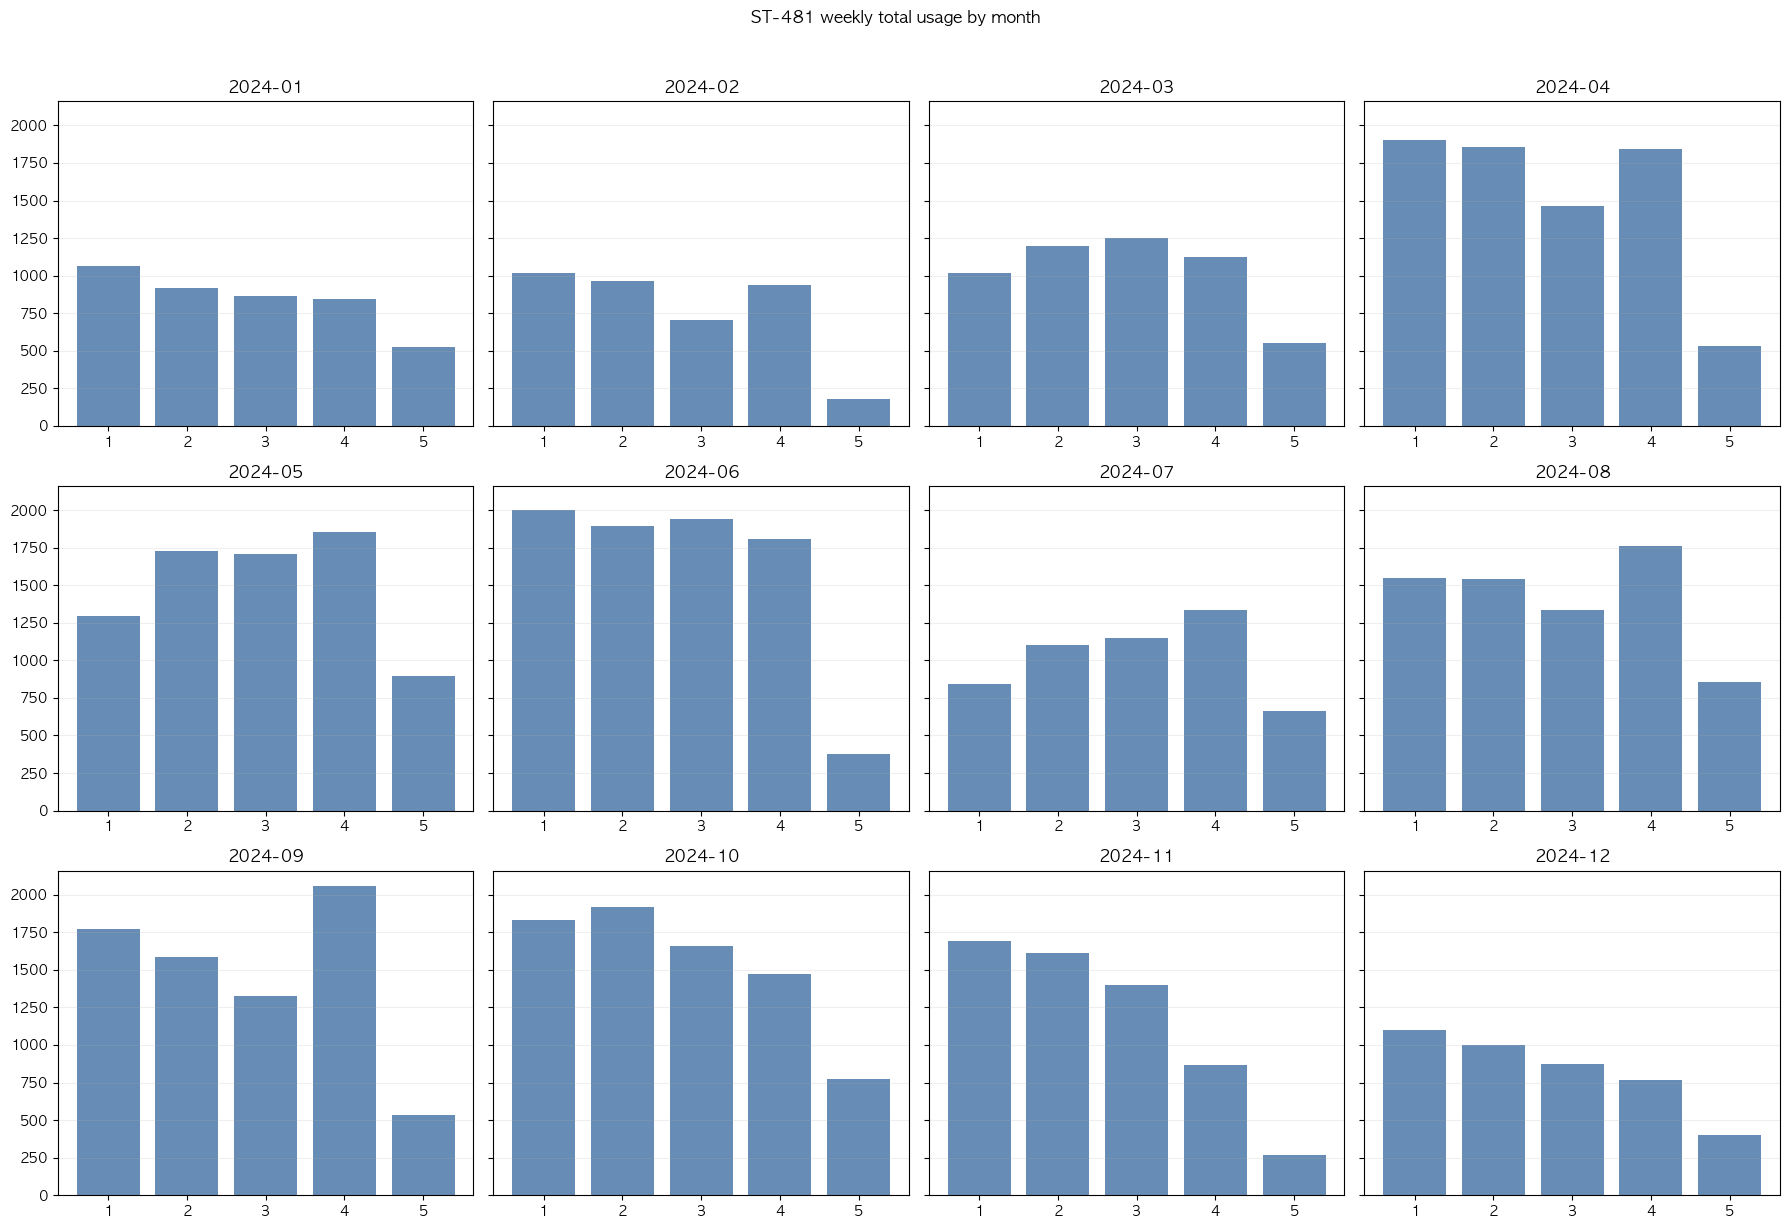

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for ax, month_label in zip(axes, sorted(monthly_weekly_usage['month_label'].unique())):
    month_data = monthly_weekly_usage[monthly_weekly_usage['month_label'] == month_label]
    ax.bar(month_data['week_of_month'], month_data['total_flow'], color='#4C78A8', alpha=0.85)
    ax.set_title(month_label)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis='y', alpha=0.2)

for ax in axes[len(monthly_weekly_usage['month_label'].unique()):]:
    ax.axis('off')

fig.suptitle(f'{station_id} weekly total usage by month', y=1.02)
fig.tight_layout()
plt.show()

In [9]:
corr_candidates = hourly.select_dtypes(include='number').copy()
constant_cols = corr_candidates.columns[corr_candidates.nunique() <= 1].tolist()
corr_candidates = corr_candidates.drop(columns=constant_cols)
corr_matrix = corr_candidates.corr()
target_cols = ['inflow', 'outflow', 'total_flow', 'net_flow']
display(corr_matrix[target_cols].sort_values('total_flow', ascending=False))
print('dropped constant columns:', constant_cols)

,inflow,outflow,total_flow,net_flow
total_flow,0.857020,0.831464,1.000000,0.083026
inflow,1.000000,0.426302,0.857020,0.584659
outflow,0.426302,1.000000,0.831464,-0.484627
시간대,0.426475,0.250728,0.404757,0.187530
is_noon,0.410636,0.208509,0.370980,0.210078
temp_lag_1hr,0.280089,0.263293,0.322007,0.034707
is_rushhour,0.249915,0.281500,0.313847,-0.010800
온도,0.254090,0.262610,0.305651,0.010179
net_flow,0.584659,-0.484627,0.083026,1.000000
weekday_2,0.048523,0.028142,0.045833,0.021681


dropped constant columns: ['위도', '경도', 'year', 'transit_index', 'commute_in_index', 'commute_out_index']


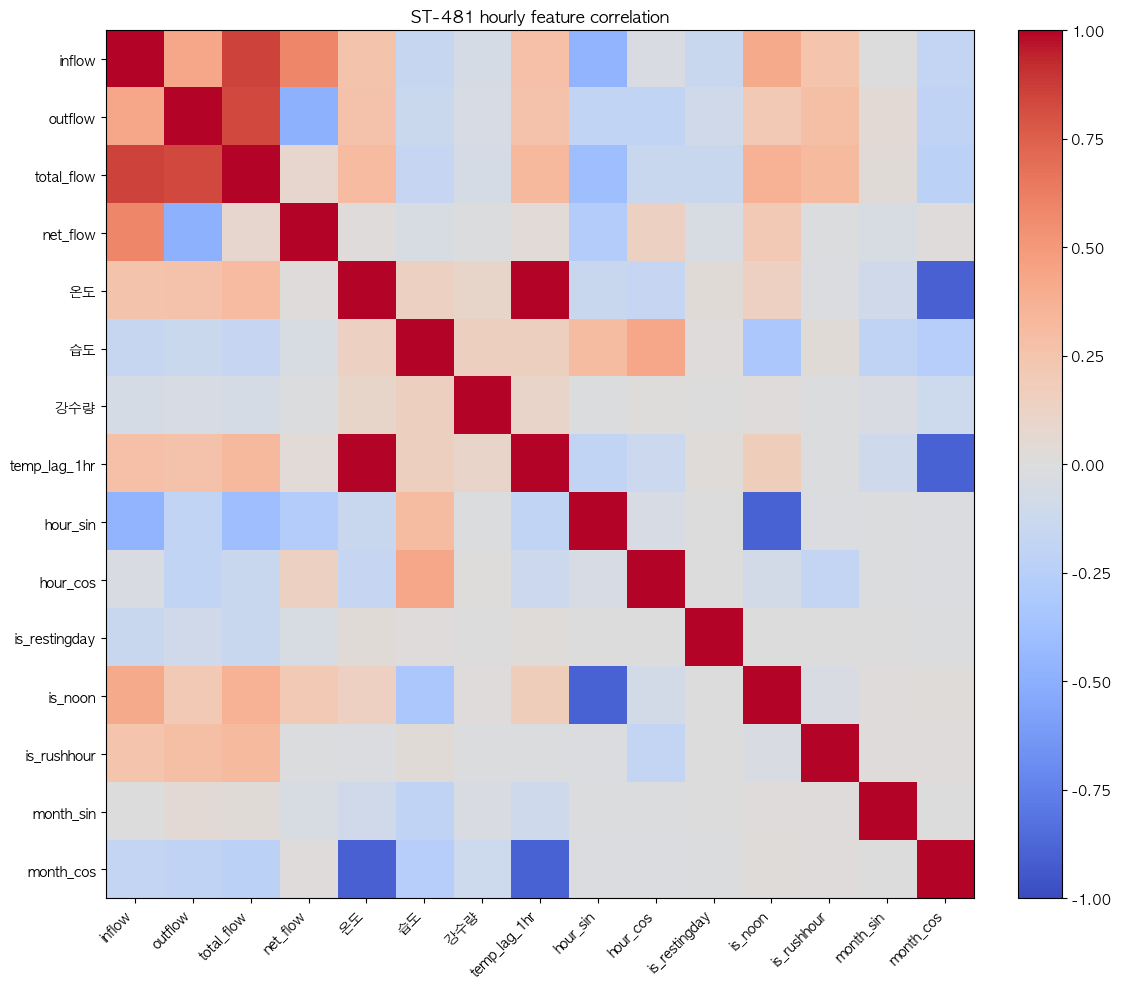

In [10]:
plot_cols = ['inflow', 'outflow', 'total_flow', 'net_flow', '온도', '습도', '강수량', 'temp_lag_1hr', 'hour_sin', 'hour_cos', 'is_restingday', 'is_noon', 'is_rushhour', 'month_sin', 'month_cos']
plot_cols = [col for col in plot_cols if col in corr_matrix.columns]
plot_corr = corr_matrix.loc[plot_cols, plot_cols]

plt.figure(figsize=(12, 10))
im = plt.imshow(plot_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(plot_cols)), plot_cols, rotation=45, ha='right')
plt.yticks(range(len(plot_cols)), plot_cols)
plt.title(f'{station_id} hourly feature correlation')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [11]:
candidate_features = [col for col in corr_matrix.columns if col not in ['inflow', 'outflow', 'total_flow', 'net_flow']]

feature_priority = {
    target: corr_matrix.loc[candidate_features, target].abs().sort_values(ascending=False)
    for target in ['inflow', 'outflow', 'total_flow', 'net_flow']
}

for target, series in feature_priority.items():
    print(f'\n[{target}] top features')
    display(series.head(10).to_frame(name='abs_corr'))

selected_features = sorted(set(
    feature_priority['total_flow'].head(8).index.tolist()
    + feature_priority['inflow'].head(8).index.tolist()
    + feature_priority['outflow'].head(8).index.tolist()
))

print('\nrecommended features for first model:')
print(selected_features)


[inflow] top features


,abs_corr
hour_sin,0.462875
시간대,0.426475
is_noon,0.410636
temp_lag_1hr,0.280089
온도,0.254090
is_rushhour,0.249915
month_cos,0.175709
습도,0.159687
is_restingday,0.135234
business_index,0.121675



[outflow] top features


,abs_corr
is_rushhour,0.281500
temp_lag_1hr,0.263293
온도,0.262610
시간대,0.250728
is_noon,0.208509
month_cos,0.201560
hour_cos,0.193220
hour_sin,0.191832
business_index,0.149282
습도,0.126797



[total_flow] top features


,abs_corr
시간대,0.404757
hour_sin,0.393564
is_noon,0.370980
temp_lag_1hr,0.322007
is_rushhour,0.313847
온도,0.305651
month_cos,0.222733
습도,0.170305
business_index,0.159767
is_restingday,0.138175



[net_flow] top features


,abs_corr
hour_sin,0.275550
is_noon,0.210078
시간대,0.187530
hour_cos,0.135898
is_restingday,0.043991
month_sin,0.042280
습도,0.040697
month,0.037425
weekday_6,0.036144
temp_lag_1hr,0.034707



recommended features for first model:
['hour_cos', 'hour_sin', 'is_noon', 'is_rushhour', 'month_cos', 'temp_lag_1hr', '습도', '시간대', '온도']


In [12]:
drop_for_linear_regression = [
    'timestamp', '기준_날짜', '집계_기준', 'station_id',
    '위도', '경도', 'year',
    'temp_lag_1hr',
    'month',
    '시간대', 'is_noon', 'is_rushhour',
    'weekday_0',
    'residential_index', 'business_index', 'tourism_index',
    'transit_index', 'commute_in_index', 'commute_out_index'
]

keep_for_linear_regression = [
    '온도', '습도', '강수량',
    'month_sin', 'month_cos',
    'hour_sin', 'hour_cos',
    'is_restingday',
    'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
    'snow_flag'
]

linear_regression_features = [col for col in keep_for_linear_regression if col in hourly.columns]

print('drop_for_linear_regression')
print(drop_for_linear_regression)
print('\nkeep_for_linear_regression')
print(linear_regression_features)

X_linear = hourly[linear_regression_features].copy()
display(X_linear.head())

drop_for_linear_regression
['timestamp', '기준_날짜', '집계_기준', 'station_id', '위도', '경도', 'year', 'temp_lag_1hr', 'month', '시간대', 'is_noon', 'is_rushhour', 'weekday_0', 'residential_index', 'business_index', 'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index']

keep_for_linear_regression
['온도', '습도', '강수량', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_restingday', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'snow_flag']


,온도,습도,강수량,month_sin,month_cos,hour_sin,hour_cos,is_restingday,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,snow_flag
0,-2.7,92,0.0,0.0,1.0,0.000000,1.000000,1,0,0,0,0,0,0,0
1,-1.2,87,0.0,0.0,1.0,0.258819,0.965926,1,0,0,0,0,0,0,0
2,-1.2,88,0.0,0.0,1.0,0.500000,0.866025,1,0,0,0,0,0,0,0
3,-1.1,88,0.0,0.0,1.0,0.707107,0.707107,1,0,0,0,0,0,0,0
4,-1.0,87,0.0,0.0,1.0,0.965926,0.258819,1,0,0,0,0,0,0,0


In [13]:
split_idx = int(len(hourly) * 0.8)

X = hourly[linear_regression_features].copy()
y_inflow = hourly['inflow'].copy()
y_outflow = hourly['outflow'].copy()

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_inflow_train, y_inflow_test = y_inflow.iloc[:split_idx], y_inflow.iloc[split_idx:]
y_outflow_train, y_outflow_test = y_outflow.iloc[:split_idx], y_outflow.iloc[split_idx:]

print('train shape:', X_train.shape)
print('test shape:', X_test.shape)

train shape: (6126, 15)
test shape: (1532, 15)


In [14]:
inflow_model = LinearRegression()
outflow_model = LinearRegression()

inflow_model.fit(X_train, y_inflow_train)
outflow_model.fit(X_train, y_outflow_train)

inflow_pred = inflow_model.predict(X_test)
outflow_pred = outflow_model.predict(X_test)

metrics_df = pd.DataFrame([
    {
        'target': 'inflow',
        'mae': mean_absolute_error(y_inflow_test, inflow_pred),
        'rmse': mean_squared_error(y_inflow_test, inflow_pred) ** 0.5,
        'r2': r2_score(y_inflow_test, inflow_pred),
    },
    {
        'target': 'outflow',
        'mae': mean_absolute_error(y_outflow_test, outflow_pred),
        'rmse': mean_squared_error(y_outflow_test, outflow_pred) ** 0.5,
        'r2': r2_score(y_outflow_test, outflow_pred),
    }
])

display(metrics_df)

,target,mae,rmse,r2
0,inflow,2.500406,3.276204,0.257802
1,outflow,2.487484,3.235119,0.138725


In [15]:
coef_df = pd.DataFrame({
    'feature': linear_regression_features,
    'inflow_coef': inflow_model.coef_,
    'outflow_coef': outflow_model.coef_,
})

display(coef_df.sort_values('inflow_coef', ascending=False))
display(coef_df.sort_values('outflow_coef', ascending=False))

,feature,inflow_coef,outflow_coef
12,weekday_5,0.746879,1.157117
9,weekday_2,0.293800,0.442117
10,weekday_3,0.047008,0.176758
0,온도,0.007371,0.016363
1,습도,-0.015128,-0.010590
11,weekday_4,-0.032862,0.417653
8,weekday_1,-0.053498,0.228766
3,month_sin,-0.123295,0.142032
13,weekday_6,-0.135358,0.563865
6,hour_cos,-0.229014,-0.944313


,feature,inflow_coef,outflow_coef
12,weekday_5,0.746879,1.157117
13,weekday_6,-0.135358,0.563865
9,weekday_2,0.293800,0.442117
11,weekday_4,-0.032862,0.417653
8,weekday_1,-0.053498,0.228766
10,weekday_3,0.047008,0.176758
3,month_sin,-0.123295,0.142032
0,온도,0.007371,0.016363
1,습도,-0.015128,-0.010590
2,강수량,-0.402908,-0.340572


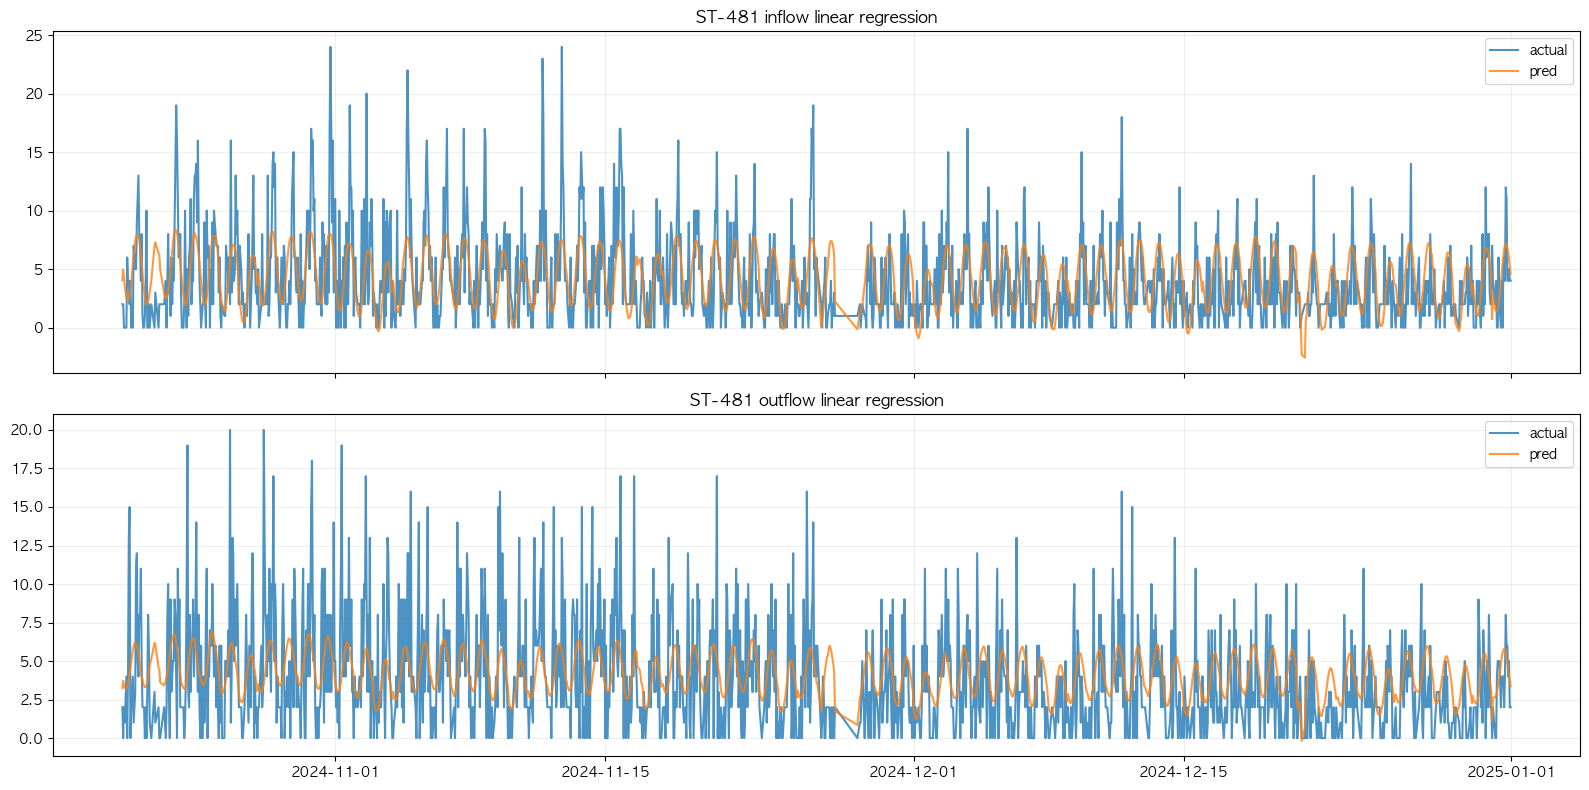

In [16]:
plot_df = pd.DataFrame({
    'timestamp': hourly['timestamp'].iloc[split_idx:],
    'inflow_actual': y_inflow_test.values,
    'inflow_pred': inflow_pred,
    'outflow_actual': y_outflow_test.values,
    'outflow_pred': outflow_pred,
})

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(plot_df['timestamp'], plot_df['inflow_actual'], label='actual', alpha=0.8)
axes[0].plot(plot_df['timestamp'], plot_df['inflow_pred'], label='pred', alpha=0.8)
axes[0].set_title(f'{station_id} inflow linear regression')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df['timestamp'], plot_df['outflow_actual'], label='actual', alpha=0.8)
axes[1].plot(plot_df['timestamp'], plot_df['outflow_pred'], label='pred', alpha=0.8)
axes[1].set_title(f'{station_id} outflow linear regression')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [17]:
hourly_full = hourly.set_index('timestamp').reindex(pd.date_range(hourly['timestamp'].min(), hourly['timestamp'].max(), freq='h'))
hourly_full.index.name = 'timestamp'

for col in ['inflow', 'outflow', 'total_flow', 'net_flow']:
    hourly_full[col] = hourly_full[col].fillna(0)

fill_cols = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
for col in fill_cols:
    hourly_full[col] = hourly_full[col].ffill().bfill()

hgb_base_features = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
display(hourly_full[hgb_base_features + ['inflow', 'outflow', 'total_flow']].head())

,온도,습도,강수량,snow_flag,is_restingday,month_sin,month_cos,hour_sin,hour_cos,inflow,outflow,total_flow
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,-2.7,92.0,0.0,0.0,1.0,0.0,1.0,0.000000,1.000000,2.0,2.0,4.0
2024-01-01 01:00:00,-1.2,87.0,0.0,0.0,1.0,0.0,1.0,0.258819,0.965926,0.0,3.0,3.0
2024-01-01 02:00:00,-1.2,88.0,0.0,0.0,1.0,0.0,1.0,0.500000,0.866025,3.0,0.0,3.0
2024-01-01 03:00:00,-1.1,88.0,0.0,0.0,1.0,0.0,1.0,0.707107,0.707107,1.0,2.0,3.0
2024-01-01 04:00:00,-1.1,88.0,0.0,0.0,1.0,0.0,1.0,0.707107,0.707107,0.0,0.0,0.0


In [18]:
hgb_validation_artifacts = {}

def run_hgb_validation(target, split_ratio=0.8, valid_ratio=0.2):
    features = hgb_base_features.copy()
    data = hourly_full.dropna(subset=features + [target]).copy()
    split_idx = int(len(data) * split_ratio)
    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()

    x_input, x_valid, y_input, y_valid = train_test_split(
        train[features],
        train[target],
        test_size=valid_ratio,
        shuffle=False
    )

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(x_input, np.log1p(y_input))
    pred_input = np.expm1(model.predict(x_input))
    pred_valid = np.expm1(model.predict(x_valid))

    final_model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    final_model.fit(train[features], np.log1p(train[target]))
    pred_test = np.expm1(final_model.predict(test[features]))

    key = target
    hgb_validation_artifacts[key] = {
        'target': target,
        'features': features,
        'model': model,
        'x_input': x_input,
        'y_input': y_input,
        'x_valid': x_valid,
        'y_valid': y_valid,
        'final_model': final_model,
        'train': train,
        'test': test,
    }

    return {
        'target': target,
        'rows': len(data),
        'input_rows': len(x_input),
        'valid_rows': len(x_valid),
        'test_rows': len(test),
        'input_r2': r2_score(y_input, pred_input),
        'valid_r2': r2_score(y_valid, pred_valid),
        'test_r2': r2_score(test[target], pred_test),
        'valid_mae': mean_absolute_error(y_valid, pred_valid),
        'test_mae': mean_absolute_error(test[target], pred_test),
        'valid_rmse': mean_squared_error(y_valid, pred_valid) ** 0.5,
        'test_rmse': mean_squared_error(test[target], pred_test) ** 0.5,
        'artifact_key': key,
    }

validation_results = pd.DataFrame([
    run_hgb_validation('inflow'),
    run_hgb_validation('outflow'),
    run_hgb_validation('total_flow'),
])

display(validation_results[['target', 'rows', 'input_rows', 'valid_rows', 'test_rows', 'input_r2', 'valid_r2', 'test_r2', 'valid_mae', 'test_mae', 'valid_rmse', 'test_rmse', 'artifact_key']])

,target,rows,input_rows,valid_rows,test_rows,input_r2,valid_r2,test_r2,valid_mae,test_mae,valid_rmse,test_rmse,artifact_key
0,inflow,8784,5621,1406,1757,0.714642,0.441479,0.427042,2.581150,2.122158,3.569373,2.882284,inflow
1,outflow,8784,5621,1406,1757,0.652865,0.303534,0.372584,2.740595,2.068946,3.757579,2.788077,outflow
2,total_flow,8784,5621,1406,1757,0.762117,0.503854,0.474010,4.184193,3.262517,5.676883,4.459873,total_flow


In [19]:
monthly_hourly_usage = (
    hourly.groupby(['month', '시간대'])[['inflow', 'outflow', 'total_flow', 'net_flow']]
          .mean()
          .reset_index()
)

monthly_hourly_usage.head(24)

,month,시간대,inflow,outflow,total_flow,net_flow
0,1,0,2.307692,1.346154,3.653846,0.961538
1,1,1,1.636364,1.409091,3.045455,0.227273
2,1,2,1.476190,1.047619,2.523810,0.428571
3,1,3,1.777778,0.666667,2.444444,1.111111
4,1,4,1.176471,0.352941,1.529412,0.823529
5,1,5,0.461538,1.461538,1.923077,-1.000000
6,1,6,1.814815,4.481481,6.296296,-2.666667
7,1,7,1.275862,4.655172,5.931034,-3.379310
8,1,8,4.866667,6.800000,11.666667,-1.933333
9,1,9,1.655172,3.896552,5.551724,-2.241379


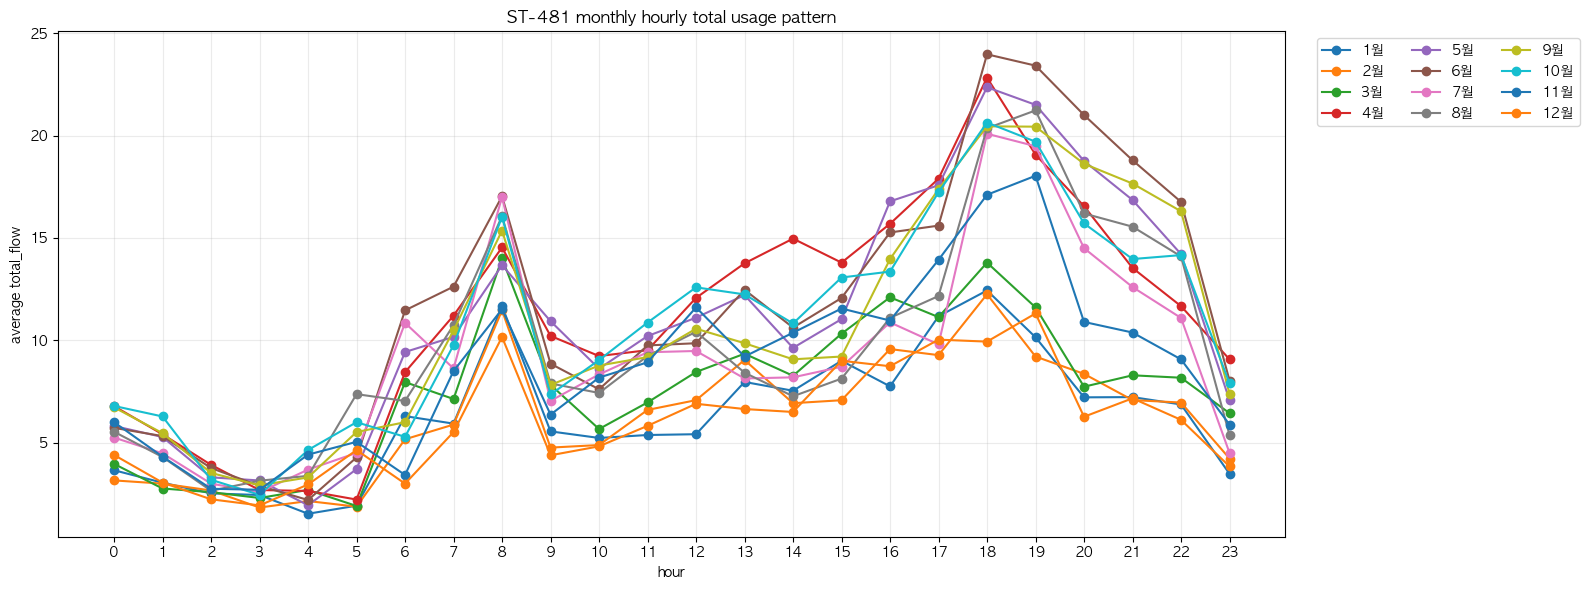

In [20]:
plt.figure(figsize=(16, 6))
for month in sorted(monthly_hourly_usage['month'].unique()):
    month_data = monthly_hourly_usage[monthly_hourly_usage['month'] == month]
    plt.plot(month_data['시간대'], month_data['total_flow'], marker='o', linewidth=1.5, label=f'{month}월')

plt.title(f'{station_id} monthly hourly total usage pattern')
plt.xlabel('hour')
plt.ylabel('average total_flow')
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

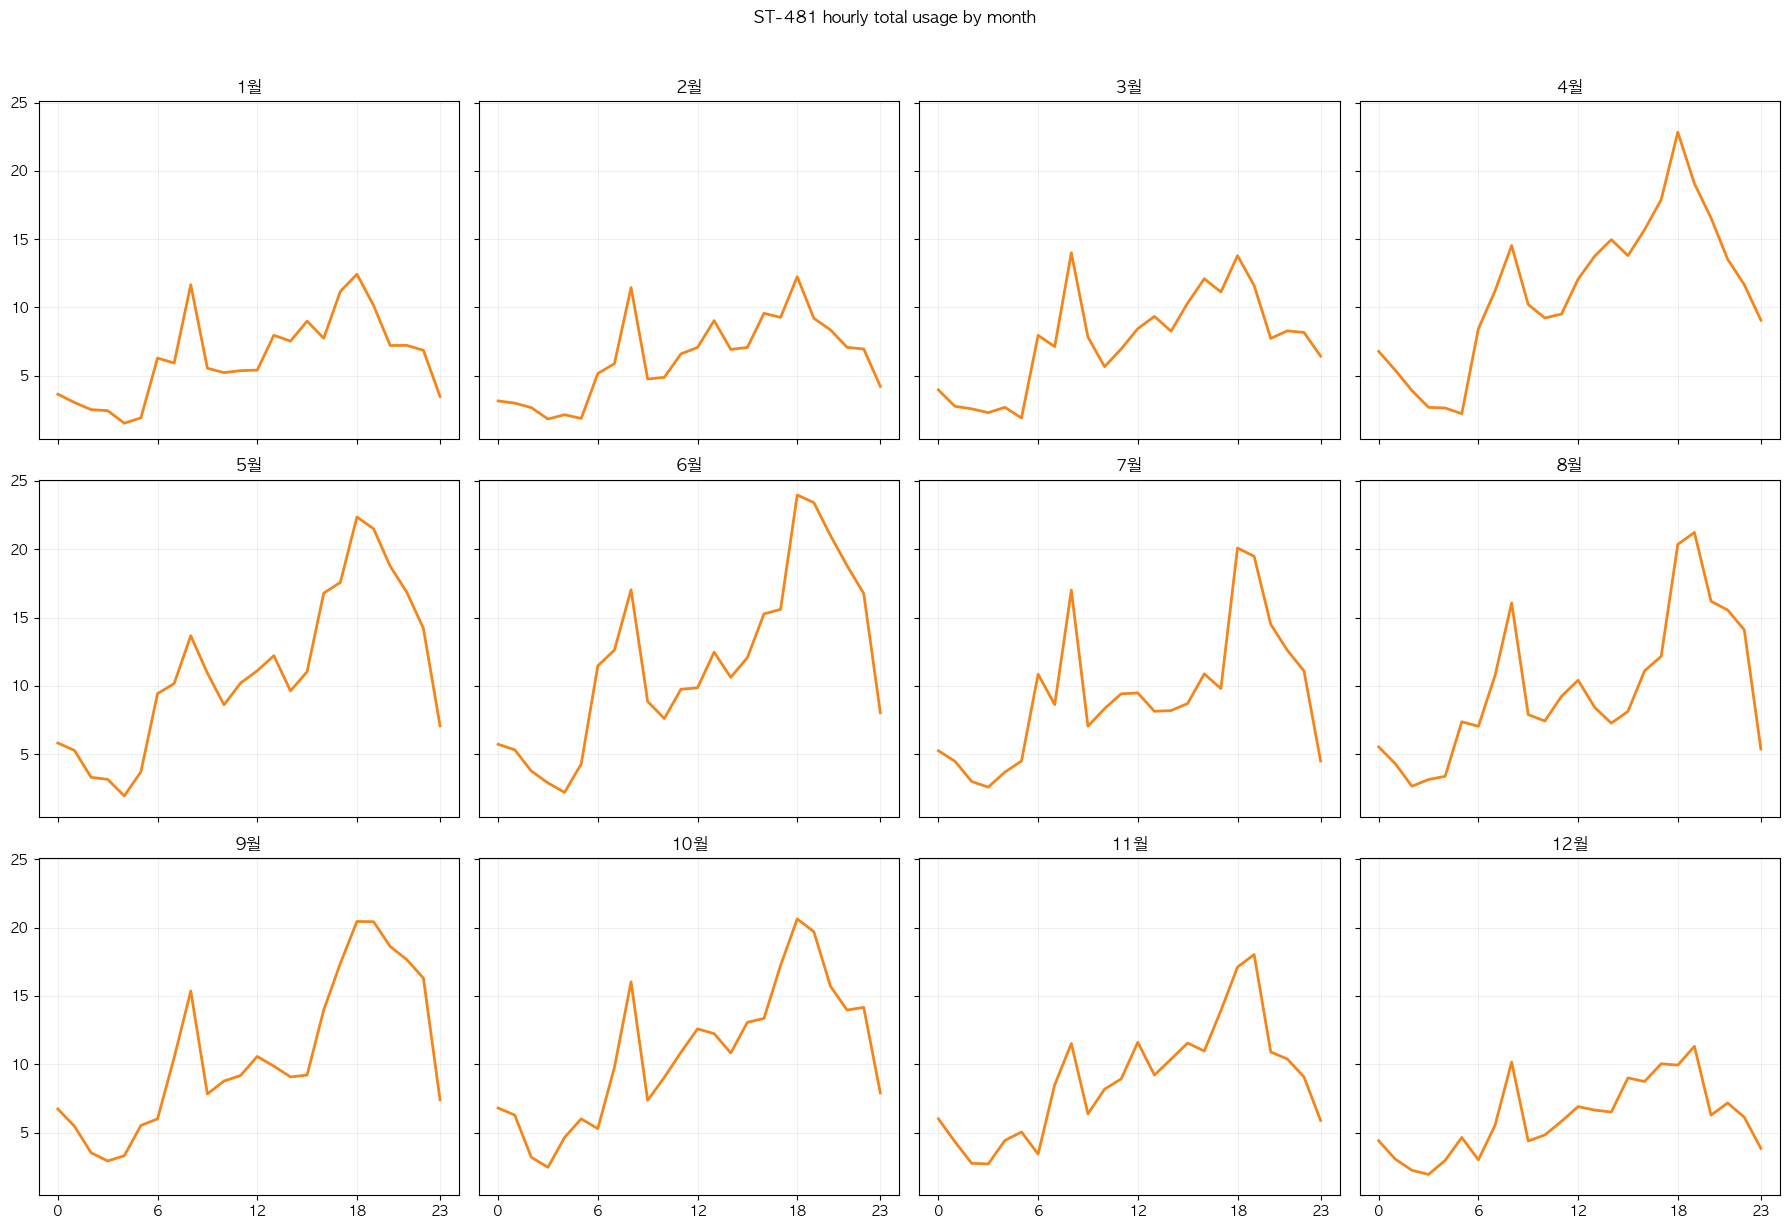

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, month in zip(axes, sorted(monthly_hourly_usage['month'].unique())):
    month_data = monthly_hourly_usage[monthly_hourly_usage['month'] == month]
    ax.plot(month_data['시간대'], month_data['total_flow'], color='#F58518', linewidth=2)
    ax.set_title(f'{month}월')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.grid(alpha=0.2)

for ax in axes[len(monthly_hourly_usage['month'].unique()):]:
    ax.axis('off')

fig.suptitle(f'{station_id} hourly total usage by month', y=1.02)
fig.tight_layout()
plt.show()

In [22]:
monthly_hourly_pivot = monthly_hourly_usage.pivot(index='month', columns='시간대', values='total_flow').sort_index()
monthly_hourly_corr = monthly_hourly_pivot.T.corr()
monthly_hourly_cos = pd.DataFrame(
    cosine_similarity(monthly_hourly_pivot),
    index=monthly_hourly_pivot.index,
    columns=monthly_hourly_pivot.index
)

display(monthly_hourly_corr.round(3))
display(monthly_hourly_cos.round(3))

month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000,0.948,0.952,0.930,0.875,0.867,0.858,0.806,0.832,0.899,0.868,0.905
2,0.948,1.000,0.959,0.939,0.897,0.884,0.873,0.831,0.858,0.923,0.874,0.891
3,0.952,0.959,1.000,0.916,0.861,0.842,0.841,0.777,0.793,0.869,0.841,0.890
4,0.930,0.939,0.916,1.000,0.946,0.916,0.854,0.839,0.893,0.940,0.927,0.879
5,0.875,0.897,0.861,0.946,1.000,0.973,0.906,0.928,0.964,0.940,0.892,0.844
6,0.867,0.884,0.842,0.916,0.973,1.000,0.941,0.956,0.964,0.926,0.856,0.816
7,0.858,0.873,0.841,0.854,0.906,0.941,1.000,0.954,0.895,0.888,0.846,0.812
8,0.806,0.831,0.777,0.839,0.928,0.956,0.954,1.000,0.961,0.923,0.872,0.827
9,0.832,0.858,0.793,0.893,0.964,0.964,0.895,0.961,1.000,0.955,0.887,0.844


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000,0.990,0.991,0.987,0.975,0.972,0.972,0.961,0.967,0.982,0.976,0.983
2,0.990,1.000,0.993,0.989,0.979,0.976,0.975,0.966,0.972,0.986,0.978,0.981
3,0.991,0.993,1.000,0.985,0.973,0.967,0.969,0.956,0.960,0.977,0.972,0.981
4,0.987,0.989,0.985,1.000,0.989,0.982,0.971,0.967,0.979,0.989,0.987,0.978
5,0.975,0.979,0.973,0.989,1.000,0.994,0.980,0.985,0.992,0.988,0.978,0.970
6,0.972,0.976,0.967,0.982,0.994,1.000,0.987,0.990,0.992,0.984,0.970,0.963
7,0.972,0.975,0.969,0.971,0.980,0.987,1.000,0.990,0.978,0.978,0.970,0.964
8,0.961,0.966,0.956,0.967,0.985,0.990,0.990,1.000,0.992,0.984,0.974,0.966
9,0.967,0.972,0.960,0.979,0.992,0.992,0.978,0.992,1.000,0.991,0.978,0.970


In [23]:
similarity_pairs = []
months = monthly_hourly_pivot.index.tolist()

for i in range(len(months)):
    for j in range(i + 1, len(months)):
        similarity_pairs.append({
            'month_1': months[i],
            'month_2': months[j],
            'corr': monthly_hourly_corr.loc[months[i], months[j]],
            'cosine': monthly_hourly_cos.loc[months[i], months[j]],
        })

similarity_pairs = pd.DataFrame(similarity_pairs).sort_values(['corr', 'cosine'], ascending=False)
display(similarity_pairs.head(10).round(3))
display(similarity_pairs.tail(10).round(3))

,month_1,month_2,corr,cosine
38,5,6,0.973,0.994
63,10,11,0.966,0.994
47,6,9,0.964,0.992
41,5,9,0.964,0.992
56,8,9,0.961,0.992
11,2,3,0.959,0.993
46,6,8,0.956,0.990
60,9,10,0.955,0.991
51,7,8,0.954,0.990
1,1,3,0.952,0.991


,month_1,month_2,corr,cosine
24,3,7,0.841,0.969
33,4,8,0.839,0.967
7,1,9,0.832,0.967
16,2,8,0.831,0.966
59,8,12,0.827,0.966
50,6,12,0.816,0.963
55,7,12,0.812,0.964
6,1,8,0.806,0.961
26,3,9,0.793,0.960
25,3,8,0.777,0.956


## 월별 군집화 설명

이 섹션은 `ST-481` 대여소의 월별 시간대 이용 패턴이 서로 비슷한지 확인하고, 비슷한 달끼리 군집을 형성하기 위한 단계입니다.

### 분석 목적
- 각 월의 시간대별 이용 패턴이 얼마나 유사한지 확인합니다.
- 유사한 달을 같은 그룹으로 묶어 계절성 또는 운영 패턴을 단순화합니다.
- 이후 전체 12개월을 그대로 쓰는 대신, 군집별 대표 월만 선택해 학습용 월을 구성할 수 있는지 확인합니다.

### 입력 데이터
- `monthly_hourly_pivot` 을 사용합니다.
- 행은 `month`, 열은 `시간대(0~23)`, 값은 해당 월의 시간대별 평균 `total_flow` 입니다.
- 즉 각 월은 길이 24의 패턴 벡터로 표현됩니다.

### 군집화 방법
- 월별 패턴 벡터를 `StandardScaler` 로 표준화합니다.
- `AgglomerativeClustering(linkage='ward')` 을 사용합니다.
- 군집 수는 고정하지 않고 `k=2~5` 범위에서 비교합니다.
- 각 `k` 에 대해 `silhouette score` 를 계산하여 가장 좋은 군집 수를 선택합니다.

### 해석 포인트
- `silhouette score` 가 높을수록 군집 간 분리는 좋고, 군집 내부 응집도는 높다고 해석할 수 있습니다.
- 이 단계의 결과는 월별 패턴을 몇 개의 시즌 그룹으로 볼 수 있는지 판단하는 근거가 됩니다.


In [24]:
cluster_input = monthly_hourly_pivot.copy()
cluster_scaled = StandardScaler().fit_transform(cluster_input)

cluster_search = []
for k in range(2, 6):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(cluster_scaled)
    cluster_search.append({
        'n_clusters': k,
        'silhouette_score': silhouette_score(cluster_scaled, labels),
    })

cluster_search = pd.DataFrame(cluster_search).sort_values('silhouette_score', ascending=False)
display(cluster_search)

,n_clusters,silhouette_score
0,2,0.447540
1,3,0.330521
2,4,0.299669
3,5,0.264311


In [25]:
best_k = int(cluster_search.iloc[0]['n_clusters'])
month_cluster_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
month_cluster_labels = month_cluster_model.fit_predict(cluster_scaled)

month_cluster_df = pd.DataFrame({
    'month': cluster_input.index,
    'cluster': month_cluster_labels
}).sort_values(['cluster', 'month']).reset_index(drop=True)

display(month_cluster_df)
display(month_cluster_df.groupby('cluster')['month'].apply(list).reset_index(name='months'))

,month,cluster
0,4,0
1,5,0
2,6,0
3,7,0
4,8,0
5,9,0
6,10,0
7,11,0
8,1,1
9,2,1


,cluster,months
0,0,"[4, 5, 6, 7, 8, 9, 10, 11]"
1,1,"[1, 2, 3, 12]"


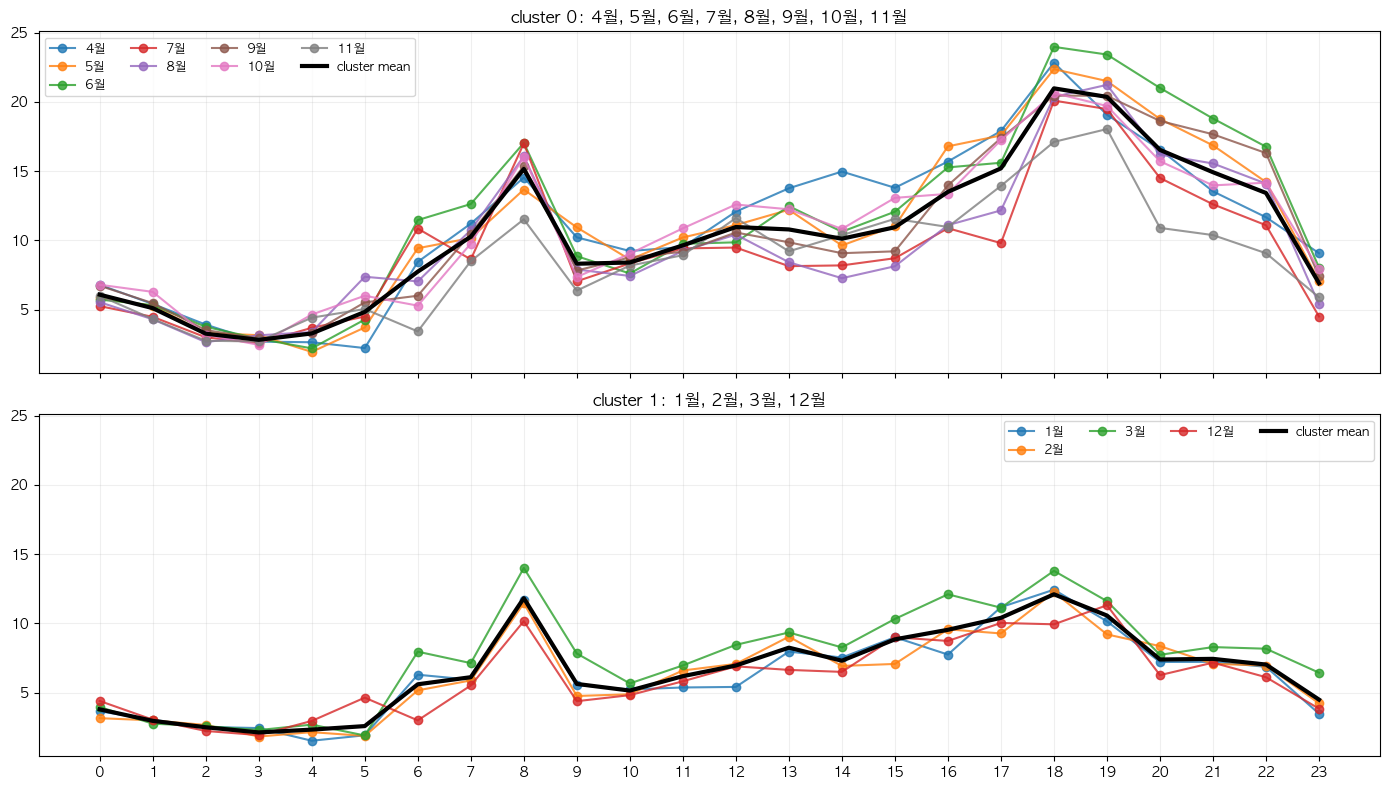

In [26]:
fig, axes = plt.subplots(best_k, 1, figsize=(14, 4 * best_k), sharex=True, sharey=True)
if best_k == 1:
    axes = [axes]

clustered_usage = monthly_hourly_usage.merge(month_cluster_df, on='month', how='left')

for cluster_id, ax in zip(sorted(clustered_usage['cluster'].unique()), axes):
    cluster_data = clustered_usage[clustered_usage['cluster'] == cluster_id]
    for month in sorted(cluster_data['month'].unique()):
        month_data = cluster_data[cluster_data['month'] == month]
        ax.plot(month_data['시간대'], month_data['total_flow'], marker='o', alpha=0.8, label=f'{month}월')

    mean_profile = cluster_data.groupby('시간대')['total_flow'].mean().reset_index()
    ax.plot(mean_profile['시간대'], mean_profile['total_flow'], color='black', linewidth=3, label='cluster mean')
    ax.set_title(f'cluster {cluster_id}: ' + ', '.join([f'{m}월' for m in sorted(cluster_data['month'].unique())]))
    ax.set_xticks(range(24))
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

## 대표 월 선택 설명

군집이 정해진 뒤에는 각 군집에서 하나의 대표 월을 선택합니다. 이 노트북에서는 최종적으로 대표 월 2개를 선택하는 방향으로 사용합니다.

### 대표 월 선택 기준
- 각 군집 안에서 월별 패턴 평균을 `cluster center` 로 계산합니다.
- 각 월이 이 중심 패턴에서 얼마나 떨어져 있는지 `distance_to_center` 로 계산합니다.
- 거리가 가장 작은 월을 해당 군집의 대표 월로 선택합니다.

### 왜 이 방식을 쓰는가?
- 대표 월은 해당 군집의 평균적인 패턴을 가장 잘 대변해야 합니다.
- 단순히 임의의 달을 고르는 것보다, 중심에 가장 가까운 달을 고르는 것이 재현성과 해석 측면에서 낫습니다.

### 최종 사용 방식
- 군집이 `2개`로 결정되면 대표 월도 `2개`가 선택됩니다.
- 이 두 달은 `selected_train_months` 로 사용합니다.
- 나머지 달은 `selected_cv_months` 로 두어 일반화 성능을 확인하는 검증용 월로 사용합니다.

즉, 전체 12개월을 그대로 쓰는 대신, 패턴을 대표하는 두 달만 학습에 사용해도 다른 달에 일반화가 가능한지 보는 실험입니다.


In [27]:
cluster_profiles = []

for cluster_id in sorted(month_cluster_df['cluster'].unique()):
    months_in_cluster = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    cluster_matrix = monthly_hourly_pivot.loc[months_in_cluster]
    cluster_center = cluster_matrix.mean(axis=0)

    for month in months_in_cluster:
        distance = np.linalg.norm(cluster_matrix.loc[month] - cluster_center)
        cluster_profiles.append({
            'cluster': cluster_id,
            'month': month,
            'distance_to_center': distance,
        })

cluster_profiles = pd.DataFrame(cluster_profiles).sort_values(['cluster', 'distance_to_center'])
representative_months = cluster_profiles.groupby('cluster', as_index=False).first()
cv_candidate_months = month_cluster_df[~month_cluster_df['month'].isin(representative_months['month'])].copy()

display(cluster_profiles.round(3))
display(representative_months.round(3))
display(cv_candidate_months)

,cluster,month,distance_to_center
6,0,10,5.721
5,0,9,5.969
1,0,5,6.846
4,0,8,7.220
0,0,4,9.103
3,0,7,9.751
2,0,6,10.019
7,0,11,12.063
8,1,1,3.192
9,1,2,3.264


,cluster,month,distance_to_center
0,0,10,5.721
1,1,1,3.192


,month,cluster
0,4,0
1,5,0
2,6,0
3,7,0
4,8,0
5,9,0
7,11,0
9,2,1
10,3,1
11,12,1


## 대표 월 2개의 8:2 분리

이 단계에서는 군집별 대표 월 2개를 선택한 뒤, 각 대표 월 내부 데이터를 시간순으로 `8:2` 비율로 분리합니다.

### 분리 방식
1. 군집별 대표 월 1개씩, 총 2개 월을 선택합니다.
2. 각 월의 시간대 데이터를 날짜순으로 정렬합니다.
3. 각 월 내부에서 앞 80%를 `train`, 뒤 20%를 `valid` 로 둡니다.
4. 두 대표 월에서 나온 `train` 조각을 합쳐 최종 `representative_train_data` 를 만들고, `valid` 조각을 합쳐 `representative_valid_data` 를 만듭니다.

이렇게 하면 월 간 경계가 섞이지 않고, 각 대표 월의 시간 흐름을 유지한 상태로 분리할 수 있습니다.


In [28]:
hourly_model_data = hourly_full.reset_index().rename(columns={'index': 'timestamp'}).copy()
hourly_model_data['month'] = hourly_model_data['timestamp'].dt.month

selected_representative_months = representative_months['month'].tolist()
representative_data = hourly_model_data[hourly_model_data['month'].isin(selected_representative_months)].copy()

representative_split_parts = []
representative_train_parts = []
representative_valid_parts = []

for month in selected_representative_months:
    month_data = representative_data[representative_data['month'] == month].sort_values('timestamp').copy()
    split_idx = int(len(month_data) * 0.8)

    month_train = month_data.iloc[:split_idx].copy()
    month_valid = month_data.iloc[split_idx:].copy()

    representative_train_parts.append(month_train)
    representative_valid_parts.append(month_valid)
    representative_split_parts.append({
        '대표월': month,
        '전체_행수': len(month_data),
        'train_행수': len(month_train),
        'valid_행수': len(month_valid),
        'train_비율': len(month_train) / len(month_data) if len(month_data) else np.nan,
        'valid_비율': len(month_valid) / len(month_data) if len(month_data) else np.nan,
        '시작시각': month_data['timestamp'].min(),
        '종료시각': month_data['timestamp'].max(),
    })

representative_train_data = pd.concat(representative_train_parts, ignore_index=True)
representative_valid_data = pd.concat(representative_valid_parts, ignore_index=True)
representative_split_summary = pd.DataFrame(representative_split_parts)

print('selected_representative_months:', selected_representative_months)
display(representative_split_summary.round(4))
print('representative_train_data rows:', len(representative_train_data))
print('representative_valid_data rows:', len(representative_valid_data))



selected_representative_months: [10, 1]


/var/folders/3l/56bkbg8s2cv9p9wd3t2313x00000gn/T/ipykernel_49995/69365756.py:36: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(representative_split_summary.round(4))


,대표월,전체_행수,train_행수,valid_행수,train_비율,valid_비율,시작시각,종료시각
0,10,744,595,149,0.7997,0.2003,2024-10-01,2024-10-31 23:00:00
1,1,744,595,149,0.7997,0.2003,2024-01-01,2024-01-31 23:00:00


representative_train_data rows: 1190
representative_valid_data rows: 298


## 대표 월 2개 기반 학습, 검증, 외부 테스트

이제 앞에서 만든 `representative_train_data` 와 `representative_valid_data` 를 사용해 학습과 검증을 수행하고, `ST-481_2025.csv` 전체 데이터를 외부 테스트셋으로 사용합니다.

### 사용 피처
- `온도`, `습도`, `강수량`, `snow_flag`, `is_restingday`, `month_sin`, `month_cos`, `hour_sin`, `hour_cos`
- `lag / rolling` 피처는 사용하지 않습니다.

### 평가 방식
- `train`: 대표 월 2개 내부의 앞 80%
- `valid`: 대표 월 2개 내부의 뒤 20%
- `test`: `ST-481_2025.csv` 전체 시간 구간을 시간축 보정 후 사용
- 지표: `R²`, `MAE`, `RMSE`


In [29]:
model_features = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

test_raw_2025 = pd.read_csv('../../../Data/sort_data/preprocessed_6station/ST-481_2025.csv')
test_raw_2025 = test_raw_2025.loc[~test_raw_2025['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()
test_raw_2025['기준_날짜'] = pd.to_datetime(test_raw_2025['기준_날짜'])
test_raw_2025['timestamp'] = test_raw_2025['기준_날짜'] + pd.to_timedelta(test_raw_2025['시간대'], unit='h')

def make_hourly_from_raw(raw_df, feature_cols):
    hourly_df = (
        raw_df.sort_values('timestamp')
        .groupby('timestamp')
        .agg(
            inflow=('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
            outflow=('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
            **{col: (col, 'first') for col in feature_cols}
        )
    )
    full_idx = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
    hourly_df = hourly_df.reindex(full_idx)
    hourly_df.index.name = 'timestamp'
    hourly_df[['inflow', 'outflow']] = hourly_df[['inflow', 'outflow']].fillna(0)
    for col in feature_cols:
        hourly_df[col] = hourly_df[col].ffill().bfill()
    hourly_df = hourly_df.reset_index()
    hourly_df['total_flow'] = hourly_df['inflow'] + hourly_df['outflow']
    hourly_df['net_flow'] = hourly_df['inflow'] - hourly_df['outflow']
    return hourly_df

test_2025_hourly = make_hourly_from_raw(test_raw_2025, model_features)

print('representative_train_data rows:', len(representative_train_data))
print('representative_valid_data rows:', len(representative_valid_data))
print('test_2025_hourly rows:', len(test_2025_hourly))
display(test_2025_hourly[['timestamp', 'inflow', 'outflow', 'total_flow']].head())


representative_train_data rows: 1190
representative_valid_data rows: 298
test_2025_hourly rows: 8567


,timestamp,inflow,outflow,total_flow
0,2025-01-09 00:00:00,3.0,0.0,3.0
1,2025-01-09 01:00:00,0.0,2.0,2.0
2,2025-01-09 02:00:00,0.0,2.0,2.0
3,2025-01-09 03:00:00,0.0,0.0,0.0
4,2025-01-09 04:00:00,0.0,0.0,0.0


In [30]:
representative_eval_artifacts = {}
representative_score_rows = []

for target in ['inflow', 'outflow', 'total_flow']:
    train_data = representative_train_data.dropna(subset=model_features + [target]).copy()
    valid_data = representative_valid_data.dropna(subset=model_features + [target]).copy()
    test_data = test_2025_hourly.dropna(subset=model_features + [target]).copy()

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(train_data[model_features], np.log1p(train_data[target]))

    pred_train = np.expm1(model.predict(train_data[model_features]))
    pred_valid = np.expm1(model.predict(valid_data[model_features]))
    pred_test = np.expm1(model.predict(test_data[model_features]))

    representative_eval_artifacts[target] = {
        'train_actual': train_data[target].reset_index(drop=True),
        'train_pred': pd.Series(pred_train),
        'valid_actual': valid_data[target].reset_index(drop=True),
        'valid_pred': pd.Series(pred_valid),
        'test_actual': test_data[target].reset_index(drop=True),
        'test_pred': pd.Series(pred_test),
    }

    representative_score_rows.append({
        '타깃': target,
        'train_행수': len(train_data),
        'valid_행수': len(valid_data),
        'test_행수': len(test_data),
        'train_R2': r2_score(train_data[target], pred_train),
        'valid_R2': r2_score(valid_data[target], pred_valid),
        'test_R2': r2_score(test_data[target], pred_test),
        'train_MAE': mean_absolute_error(train_data[target], pred_train),
        'valid_MAE': mean_absolute_error(valid_data[target], pred_valid),
        'test_MAE': mean_absolute_error(test_data[target], pred_test),
        'train_RMSE': mean_squared_error(train_data[target], pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(valid_data[target], pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(test_data[target], pred_test) ** 0.5,
    })

representative_score_table = pd.DataFrame(representative_score_rows)
representative_score_table['타깃'] = representative_score_table['타깃'].replace({
    'inflow': '유입량',
    'outflow': '유출량',
    'total_flow': '총이용량',
})
display(representative_score_table.round(4))


,타깃,train_행수,valid_행수,test_행수,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,유입량,1190,298,8567,0.8226,0.4553,0.3209,1.1918,2.2613,2.6401,1.7223,3.0464,3.6882
1,유출량,1190,298,8567,0.7995,0.3503,0.2114,1.1687,2.2263,2.2885,1.7192,3.0714,3.1126
2,총이용량,1190,298,8567,0.8631,0.5139,0.4365,1.7893,3.4657,3.8933,2.5094,4.5877,5.2570


## 대표 월 2개 기반 점수 해석

현재 대표 월 선택 결과는 `10월`, `1월` 입니다. 각 대표 월 내부를 시간순 `8:2` 로 나눈 뒤, `2025` 전체 데이터를 외부 테스트셋으로 사용한 결과는 아래와 같이 해석할 수 있습니다.

### 핵심 결과
- `유입량`: `test_R2 = 0.3209`
- `유출량`: `test_R2 = 0.2114`
- `총이용량`: `test_R2 = 0.4365`

### 해석
- 대표 월 2개만으로도 `총이용량` 은 비교적 안정적으로 예측됩니다.
- `유입량` 은 최소 기준선 수준으로는 유지되지만, `총이용량` 만큼 강하지는 않습니다.
- `유출량` 은 대표 월 2개만으로는 일반화 성능이 상대적으로 약합니다.

### 의미
- 월별 패턴을 대표하는 두 달만 사용해도 전체 계절 패턴의 일부는 설명할 수 있습니다.
- 다만 모든 타깃에서 충분한 성능이 보장되지는 않으므로, 이 결과는 `대표 월 실험 결과` 로 해석하는 것이 적절합니다.
- 특히 최종 운영 모델이라면 대표 월 2개만 쓰기보다 더 많은 월을 포함하는 방식이 안정적일 수 있습니다.


In [31]:
rows_table = representative_score_table[['타깃', 'train_행수', 'valid_행수', 'test_행수']].copy()
r2_table = representative_score_table[['타깃', 'train_R2', 'valid_R2', 'test_R2']].copy()
mae_table = representative_score_table[['타깃', 'train_MAE', 'valid_MAE', 'test_MAE']].copy()
rmse_table = representative_score_table[['타깃', 'train_RMSE', 'valid_RMSE', 'test_RMSE']].copy()

print('분할별 행 수 표')
display(rows_table)
print('분할별 R2 표')
display(r2_table.round(4))
print('분할별 MAE 표')
display(mae_table.round(4))
print('분할별 RMSE 표')
display(rmse_table.round(4))


분할별 행 수 표


,타깃,train_행수,valid_행수,test_행수
0,유입량,1190,298,8567
1,유출량,1190,298,8567
2,총이용량,1190,298,8567


분할별 R2 표


,타깃,train_R2,valid_R2,test_R2
0,유입량,0.8226,0.4553,0.3209
1,유출량,0.7995,0.3503,0.2114
2,총이용량,0.8631,0.5139,0.4365


분할별 MAE 표


,타깃,train_MAE,valid_MAE,test_MAE
0,유입량,1.1918,2.2613,2.6401
1,유출량,1.1687,2.2263,2.2885
2,총이용량,1.7893,3.4657,3.8933


분할별 RMSE 표


,타깃,train_RMSE,valid_RMSE,test_RMSE
0,유입량,1.7223,3.0464,3.6882
1,유출량,1.7192,3.0714,3.1126
2,총이용량,2.5094,4.5877,5.2570


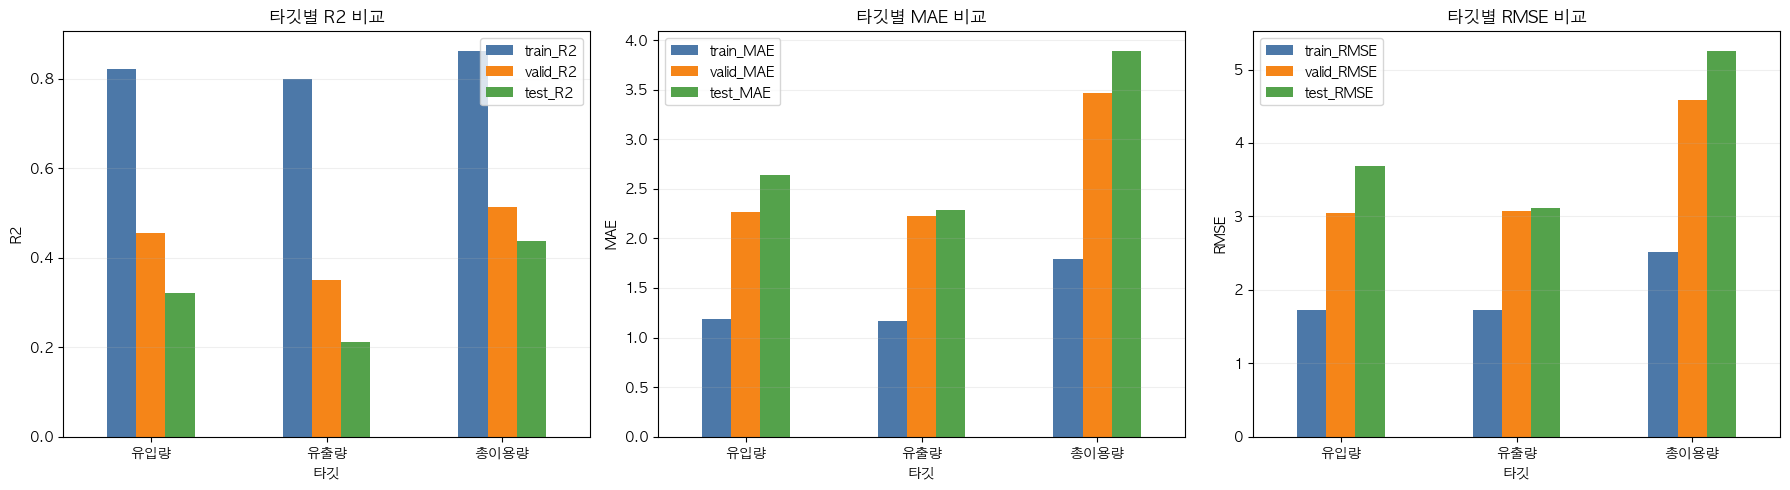

In [32]:
score_plot_df = representative_score_table.set_index('타깃')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_plot_df[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('타깃별 R2 비교')
axes[0].set_ylabel('R2')
axes[0].grid(axis='y', alpha=0.2)

score_plot_df[['train_MAE', 'valid_MAE', 'test_MAE']].plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('타깃별 MAE 비교')
axes[1].set_ylabel('MAE')
axes[1].grid(axis='y', alpha=0.2)

score_plot_df[['train_RMSE', 'valid_RMSE', 'test_RMSE']].plot(kind='bar', ax=axes[2], color=['#4C78A8', '#F58518', '#54A24B'])
axes[2].set_title('타깃별 RMSE 비교')
axes[2].set_ylabel('RMSE')
axes[2].grid(axis='y', alpha=0.2)

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


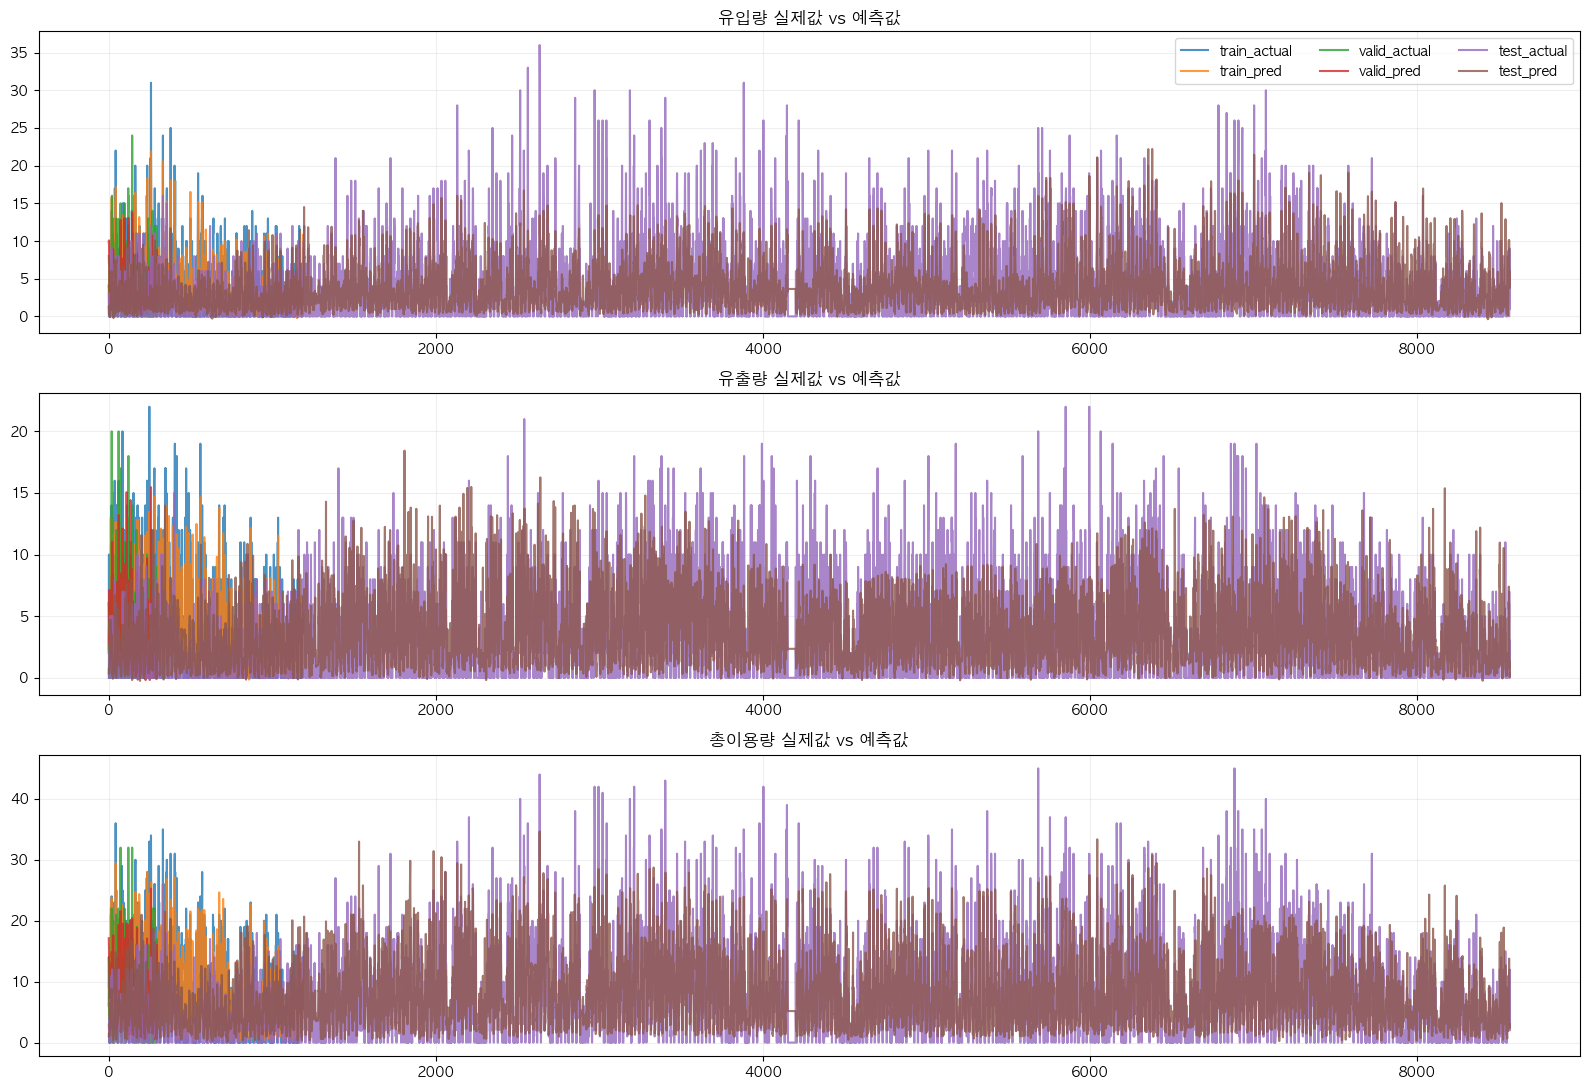

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)
target_order = [('유입량', 'inflow'), ('유출량', 'outflow'), ('총이용량', 'total_flow')]

for ax, (target_label, target_key) in zip(axes, target_order):
    art = representative_eval_artifacts[target_key]
    ax.plot(art['train_actual'], label='train_actual', alpha=0.8)
    ax.plot(art['train_pred'], label='train_pred', alpha=0.8)
    ax.plot(art['valid_actual'], label='valid_actual', alpha=0.8)
    ax.plot(art['valid_pred'], label='valid_pred', alpha=0.8)
    ax.plot(art['test_actual'], label='test_actual', alpha=0.8)
    ax.plot(art['test_pred'], label='test_pred', alpha=0.8)
    ax.set_title(f'{target_label} 실제값 vs 예측값')
    ax.grid(alpha=0.2)

axes[0].legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.show()
